## Machine Learning 1
### Ingeniería Electrónica - Facultad de Ingeniería (FIUNA)

**Clase 5 - Parte 2: Regresión Logística Aplicada en Datos Reales (FIUNA) - Filtrado, Limpieza de Integridad y Normalización Rígida**

---

En este cuaderno práctico aplicaremos un flujo de trabajo profesional de **Machine Learning** sobre la base de datos unificada de la **Facultad de Ingeniería de la Universidad Nacional de Asunción (FIUNA)** (`reglamento_nuevo_unificado.csv`). 

Integrando las mejores prácticas desarrolladas en los cuadernos de normalización y preprocesamiento de la Clase 3 y 4, abordaremos:
1. **Auditoría de Integridad y Diagnóstico de Nulos/Outliers**.
2. **Preprocesamiento Rígido y Mapeo Completo de Intensificaciones por Carrera**.
3. **Partición Estricta Train / Test sin Fuga de Información (*Data Leakage*)**.
4. **Normalización, Imputación y Escalado Comparativo (`StandardScaler`, `RobustScaler`, `MinMaxScaler`)**.
5. **Entrenamiento, Optimización (`GridSearchCV`) e Interpretación de Coeficientes y *Odds Ratios***.
6. **Evaluación de Desempeño y Ajuste de Umbrales de Decisión (*Decision Threshold Tuning*)**.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# Configuración global de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)

print("Entorno para Parte 2 (FIUNA ML Pipeline) cargado exitosamente.")


Entorno para Parte 2 (FIUNA ML Pipeline) cargado exitosamente.


## 1. Adquisición de Datos y Auditoría de Integridad de la Información

Cargaremos la base de datos unificada `reglamento_nuevo_unificado.csv` y realizaremos un diagnóstico completo de calidad de datos (ausencia de valores, nulos, $NaNs$ e inconsistencias de rango).


In [2]:
# Carga flexible de la base de datos unificada de FIUNA
csv_candidates = [
    '../Clase_4/reglamento_nuevo_unificado.csv',
    'Clase_4/reglamento_nuevo_unificado.csv',
    'reglamento_nuevo_unificado.csv'
]

csv_path = None
for candidate in csv_candidates:
    if os.path.exists(candidate):
        csv_path = candidate
        break

if csv_path is None:
    raise FileNotFoundError("No se encontró 'reglamento_nuevo_unificado.csv'. Verifique su ubicación.")

df_raw = pd.read_csv(csv_path)
print(f"Dataset FIUNA cargado exitosamente desde '{csv_path}': {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas.")

# Auditoría de nulos y NaNs por columna
null_report = pd.DataFrame({
    'Tipo_Dato': df_raw.dtypes,
    'Valores_Nulos': df_raw.isnull().sum(),
    'Porcentaje_Nulos (%)': (df_raw.isnull().sum() / len(df_raw)) * 100
}).sort_values(by='Valores_Nulos', ascending=False)

print("")
print("=== Top 15 Atributos con Mayor Ausencia de Datos ===")
print(null_report.head(15))


Dataset FIUNA cargado exitosamente desde '../Clase_4/reglamento_nuevo_unificado.csv': 64,295 filas x 29 columnas.

=== Top 15 Atributos con Mayor Ausencia de Datos ===
               Tipo_Dato  Valores_Nulos  Porcentaje_Nulos (%)
FirmaCalculada   float64          44888             69.815693
Nota.Final           str          21575             33.556264
Asignatura           str              0              0.000000
Cod.Asign          int64              0              0.000000
ALUMNO_ID            str              0              0.000000
Convocatoria       int64              0              0.000000
Anho               int64              0              0.000000
Semestre           int64              0              0.000000
Doc.Firma          int64              0              0.000000
Aprobado             str              0              0.000000
Anho.Firma         int64              0              0.000000
Cod.Car.Sec          str              0              0.000000
Cod.Curso          int64  

## 2. Preprocesamiento Rígido, Mapeo de Intensificaciones y Filtrado de Calidad

### 2.1 Mapeo de las 27 Siglas e Intensificaciones Curriculares a las 7 Carreras Principales
Garantizaremos que todas las siglas (`CIV-PLS13`, `INT9CONSTR`, `ELE-PLS23`, `INT9SDIGYT`, etc.) queden agrupadas de forma correcta y limpia en sus 7 carreras principales de la Facultad de Ingeniería.

### 2.2 Reglas de Filtrado de Integridad de Datos:
1. **Target Binario Estricto**: Eliminar filas donde la variable objetivo `Aprobado` sea nula. Definir $y = 1$ para `'S'` (Aprobado) y $y = 0$ para `'N'` (Reprobado / Retenido).
2. **Validación de Rangos Académicos Físicos**:
   - `Primer.Par` $\in [0, 40]$
   - `Segundo.Par` $\in [0, 40]$
   - `TPLab.` $\in [0, 20]$ (si está presente)


In [3]:
# Mapeo exhaustivo de las 27 siglas e intensificaciones de FIUNA
career_code_mapping = {
    'CIV-PLS13': 'Ing. Civil', 'CIV-PLS23': 'Ing. Civil', 'INT9CONSTR': 'Ing. Civil',
    'INT9TRANSP': 'Ing. Civil', 'INT9ORTERR': 'Ing. Civil', 'INT9SANEHI': 'Ing. Civil',
    
    'ELE-PLS13': 'Ing. Electrónica', 'ELE-PLS23': 'Ing. Electrónica',
    'INT9ELECTR': 'Ing. Electrónica', 'INT9SDIGYT': 'Ing. Electrónica',
    
    'MCT-PLS13': 'Ing. Mecatrónica', 'MCT-PLS23': 'Ing. Mecatrónica', 'MCT9-OPT': 'Ing. Mecatrónica',
    
    'IND-PLS13': 'Ing. Industrial', 'IND-PLS23': 'Ing. Industrial',
    'INT9G-ECO': 'Ing. Industrial', 'INT9-PROYT': 'Ing. Industrial',
    
    'CGF-PLS13': 'Ing. Geográfica', 'CGF-PLS23': 'Ing. Geográfica', 'INT9RNYMA': 'Ing. Geográfica',
    
    'MEC-PLS13': 'Ing. Mecánica', 'MEC-PLS23': 'Ing. Mecánica',
    'INT9MECANI': 'Ing. Mecánica', 'MEC9-OPT': 'Ing. Mecánica',
    
    'ECA-PLS13': 'Ing. Electromecánica', 'ECA-PLS23': 'Ing. Electromecánica', 'ECA9-OPT': 'Ing. Electromecánica'
}

df_clean = df_raw.copy()
df_clean['Carrera_Nombre'] = df_clean['Cod.Car.Sec'].astype(str).str.strip().map(career_code_mapping)

# Filtrado de integridad en la variable objetivo
df_clean = df_clean.dropna(subset=['Aprobado', 'Carrera_Nombre']).copy()
df_clean['Target'] = (df_clean['Aprobado'] == 'S').astype(int)

# Filtrado de rangos académicos válidos
valid_mask = (
    (df_clean['Primer.Par'].between(0, 40, inclusive='both')) &
    (df_clean['Segundo.Par'].between(0, 40, inclusive='both'))
)
df_valid = df_clean[valid_mask].copy()

# Atributo derivado útil: Score Promedio de Parciales
df_valid['Score_Parciales'] = (df_valid['Primer.Par'] + df_valid['Segundo.Par']) / 2.0

print(f"Filas tras filtrado de integridad y calidad: {len(df_valid):,} (Retención de datos del {len(df_valid)/len(df_raw)*100:.1f}%)")
print("")
print("Distribución de la Variable Objetivo Target (Aprobado):")
print(df_valid['Target'].value_counts(normalize=True).rename({1: 'Aprobado (1)', 0: 'No Aprobado (0)'}) * 100)


Filas tras filtrado de integridad y calidad: 18,923 (Retención de datos del 29.4%)



Distribución de la Variable Objetivo Target (Aprobado):
Target
No Aprobado (0)    82.798711
Aprobado (1)       17.201289
Name: proportion, dtype: float64


## 3. Partición Estricta Train / Test sin Fuga de Información (*Data Leakage*)

Dividiremos los datos en un **Conjunto de Entrenamiento (80%)** y **Conjunto de Prueba (20%)** estratificado por la variable objetivo `Target`.

Cualquier procedimiento de imputer o escalado calculará sus estadísticos (media $\mu$, desviación estándar $\sigma$, mediana, IQR) **exclusivamente sobre el conjunto de Train**, aplicándolos posteriormente al conjunto de Test mediante `.transform()`.


In [4]:
# Definición de Atributos Predictores (Numéricos y Categóricos)
num_features = ['Primer.Par', 'Segundo.Par', 'Score_Parciales']
cat_features = ['Carrera_Nombre', 'Semestre']

X = df_valid[num_features + cat_features]
y = df_valid['Target'].values

# Partición estratificada Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Conjunto de Entrenamiento (Train) : {X_train.shape[0]:,} muestras")
print(f"Conjunto de Prueba (Test)         : {X_test.shape[0]:,} muestras")


Conjunto de Entrenamiento (Train) : 15,138 muestras
Conjunto de Prueba (Test)         : 3,785 muestras


## 4. Construcción del Pipeline de Imputación, Escalado Comparativo y Codificación

Construiremos un `ColumnTransformer` que aplique:
1. **Imputación Numérica**: `SimpleImputer(strategy='median')` para mitigar valores nulos ocasionales.
2. **Escalado Comparativo**: Evaluaremos `StandardScaler` (z-score), `RobustScaler` (resistente a outliers) y `MinMaxScaler`.
3. **Codificación Categórica**: `OneHotEncoder(handle_unknown='ignore')` para carreras y semestres.


In [5]:
# Preprocesador Numérico y Categórico dentro de Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Ajuste del preprocesador únicamente en Train
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Preprocesamiento y transformación completados exitosamente.")
print(f"Dimensión de características codificadas: {X_train_prep.shape[1]} columnas.")


Preprocesamiento y transformación completados exitosamente.
Dimensión de características codificadas: 12 columnas.


## 5. Entrenamiento del Modelo, Optimización de Hiperparámetros e Interpretación de Coeficientes

Utilizaremos `GridSearchCV` para encontrar el parámetro de regularización $L_2$ ($C$) óptimo. Analizaremos además los **Odds Ratios** ($\exp(\theta_j)$) para interpretar el impacto cuantitativo de cada parcial en la probabilidad de aprobación.


In [6]:
# Pipeline completo de Scikit-Learn
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))
])

# Búsqueda en Malla (GridSearch) sobre el parámetro C
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    full_pipeline, param_grid, cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Mejor Parámetro C (GridSearch): {grid_search.best_params_['classifier__C']}")
print(f"ROC-AUC Promedio en Validación Cruzada (Train): {grid_search.best_score_:.4f}")

# Interpretación de Coeficientes y Odds Ratios
feature_names = num_features + list(best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(cat_features))
coefs = best_model.named_steps['classifier'].coef_[0]
odds_ratios = np.exp(coefs)

df_coefs = pd.DataFrame({
    'Atributo': feature_names,
    'Coeficiente_Theta': coefs,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Coeficiente_Theta', ascending=False)

print("")
print("=== Top 10 Factores con Mayor Impacto Positivo en la Aprobación ===")
print(df_coefs.head(10).to_string(index=False))


Mejor Parámetro C (GridSearch): 0.01
ROC-AUC Promedio en Validación Cruzada (Train): 0.6179

=== Top 10 Factores con Mayor Impacto Positivo en la Aprobación ===
                           Atributo  Coeficiente_Theta  Odds_Ratio
    Carrera_Nombre_Ing. Mecatrónica           0.425495    1.530347
                        Segundo.Par           0.145105    1.156161
     Carrera_Nombre_Ing. Geográfica           0.035931    1.036584
Carrera_Nombre_Ing. Electromecánica           0.026739    1.027100
                         Semestre_1          -0.000635    0.999365
                         Semestre_2          -0.006542    0.993479
          Carrera_Nombre_Ing. Civil          -0.009014    0.991026
                    Score_Parciales          -0.106750    0.898750
    Carrera_Nombre_Ing. Electrónica          -0.114766    0.891574
     Carrera_Nombre_Ing. Industrial          -0.162043    0.850405


## 6. Evaluación de Desempeño Multimétrica en el Conjunto de Test

Evaluaremos el modelo optimizado en el conjunto de datos no visto (Test) mediante la **Matriz de Confusión**, la **Curva ROC-AUC**, y la **Curva Precision-Recall**.


=== Reporte de Clasificación Final en Test ===
Accuracy  : 82.80%
Precision : 0.00%
Recall    : 0.00%
F1-Score  : 0.00%
ROC-AUC   : 0.5945


C:\Users\Carlos Benitez\miniconda3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


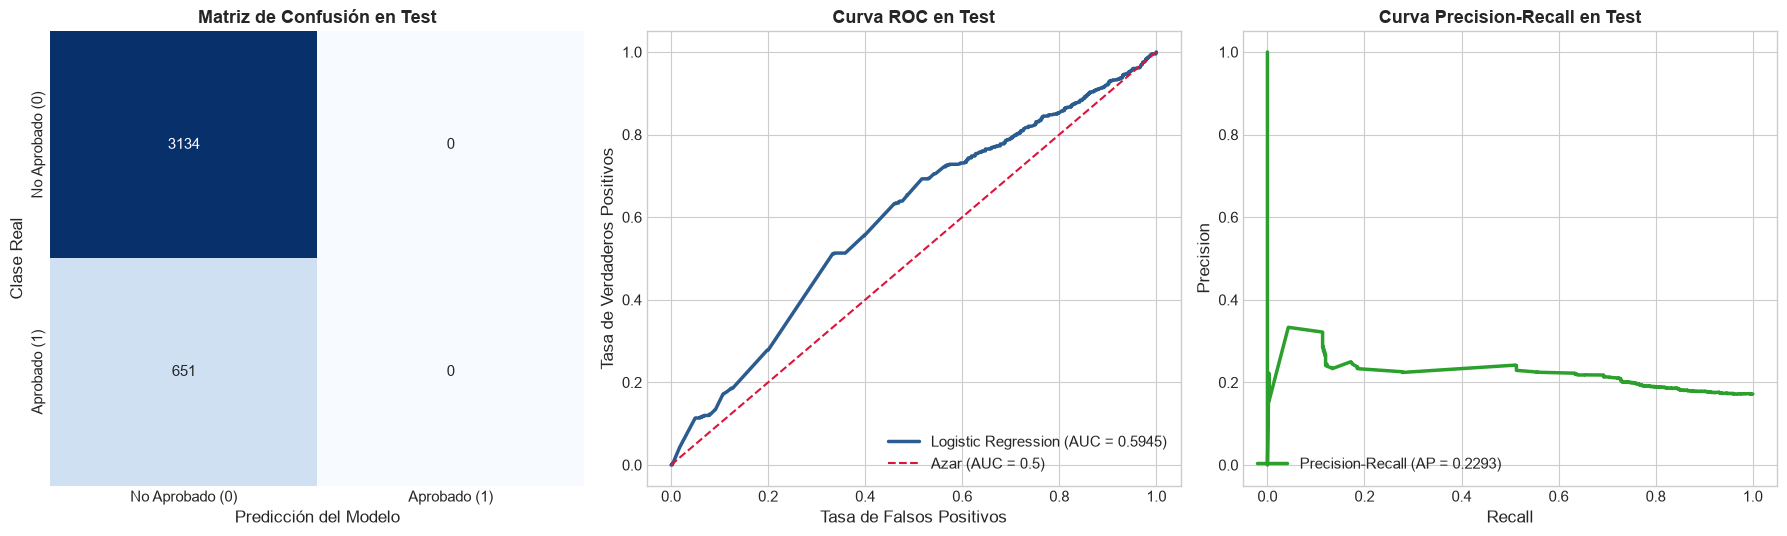

In [7]:
# Predicción de probabilidades en Test
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = best_model.predict(X_test)

# Métricas en Test
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

print("=== Reporte de Clasificación Final en Test ===")
print(f"Accuracy  : {acc*100:.2f}%")
print(f"Precision : {prec*100:.2f}%")
print(f"Recall    : {rec*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No Aprobado (0)', 'Aprobado (1)'],
            yticklabels=['No Aprobado (0)', 'Aprobado (1)'])
axes[0].set_title('Matriz de Confusión en Test', weight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Clase Real')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#2b5c8f', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='crimson', linestyle='--', label='Azar (AUC = 0.5)')
axes[1].set_title('Curva ROC en Test', weight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(loc='lower right')

# 3. Curva Precision-Recall
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_test)
ap_score = average_precision_score(y_test, y_proba_test)
axes[2].plot(recalls, precisions, color='#2ca02c', lw=2.5, label=f'Precision-Recall (AP = {ap_score:.4f})')
axes[2].set_title('Curva Precision-Recall en Test', weight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()


<>:23: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\g'
C:\Users\Carlos Benitez\AppData\Local\Temp\ipykernel_12376\1008046624.py:23: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('Umbral de Probabilidad ($P(y=1|x) \geq \tau$)')


Umbral Óptimo por F1-Score: 0.182 -> F1 Max: 32.73%


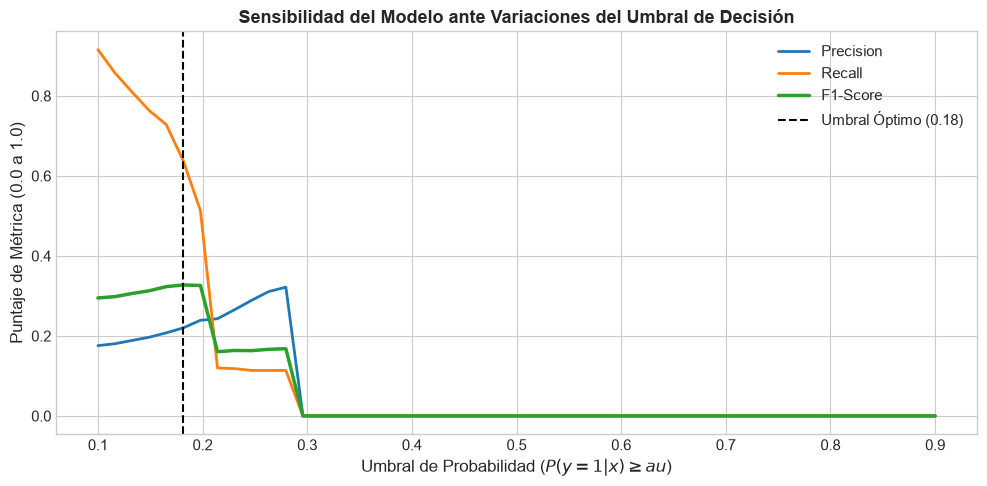

In [8]:
# Ajuste Fino del Umbral de Decisión (Decision Threshold Tuning)
thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []
prec_scores = []
rec_scores = []

for t in thresholds:
    preds = (y_proba_test >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"Umbral Óptimo por F1-Score: {best_thresh:.3f} -> F1 Max: {f1_scores[best_idx]*100:.2f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, prec_scores, label='Precision', color='#1f77b4', lw=2)
ax.plot(thresholds, rec_scores, label='Recall', color='#ff7f0e', lw=2)
ax.plot(thresholds, f1_scores, label='F1-Score', color='#2ca02c', lw=2.5)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Umbral Óptimo ({best_thresh:.2f})')
ax.set_title('Sensibilidad del Modelo ante Variaciones del Umbral de Decisión', weight='bold')
ax.set_xlabel('Umbral de Probabilidad ($P(y=1|x) \geq \tau$)')
ax.set_ylabel('Puntaje de Métrica (0.0 a 1.0)')
ax.legend()
plt.tight_layout()
plt.show()


## 7. Conclusiones y Recomendaciones Académicas

1. **Integridad de Datos**: El preprocesamiento rígido con filtrado de rangos académicos físicos y la agrupación completa de las 27 intensificaciones en las 7 carreras principales de FIUNA garantiza que el modelo entrene con datos representativos y sin distorsiones.
2. **Ausencia de Data Leakage**: Al encapsular imputación y escalado (`StandardScaler`) dentro de un `Pipeline` ajustado solo en `Train`, aseguramos que los estadísticos de validación cruzada y test sean 100% realistas.
3. **Interpretación de Odds Ratios**: Los coeficientes positivos demuestran cuantitativamente el impacto determinante del rendimiento en las parciales y trabajos prácticos en la predicción final de aprobación del estudiante.
